#Mini Project: DEG Analysis on PCOS dataset - EDA PreProcessing
by Ananya V

### Download Results Folder


## Setup Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
print("All libraries imported!")


All libraries imported!


## Defining Paths

In [3]:
url = 'https://drive.google.com/file/d/1HTss3LqWylRxpMen49IwgjVdsC8evCQ-/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
INPUT_FILE  = path
OUTPUT_DIR  = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[INFO] Data Path: {INPUT_FILE}")
print(f"[INFO] Output Directory: {OUTPUT_DIR}")

[INFO] Data Path: https://drive.google.com/uc?export=download&id=1HTss3LqWylRxpMen49IwgjVdsC8evCQ-
[INFO] Output Directory: outputs


## Load Dataset

In [4]:
print("Loading data...")
df = pd.read_csv(INPUT_FILE, sep="\t", index_col=0, low_memory=False)
print(f"  Raw shape: {df.shape}")   # genes x (samples + annotation columns)

# Separate expression vs annotation
ANNOTATION_COLS = [
    "gene_Dbxref", "coding_type", "description",
    "pathway", "pathway_description",
    "GO_ID", "GO_term",
    "wiki_ID", "wiki_term",
    "Reactome_ID", "Reactome_term"
]

# Sample columns
expr_cols   = [c for c in df.columns if c.startswith("Control") or c.startswith("PCOS")]
annot_df    = df[ANNOTATION_COLS].copy()
expr_df     = df[expr_cols].copy().astype(float)

print(f"  Expression matrix: {expr_df.shape[0]} genes × {expr_df.shape[1]} samples")
print(f"  Controls: {sum(c.startswith('Control') for c in expr_cols)}  |  PCOS: {sum(c.startswith('PCOS') for c in expr_cols)}")

Loading data...
  Raw shape: (28001, 51)
  Expression matrix: 28001 genes × 40 samples
  Controls: 17  |  PCOS: 23


## Filter lowly expressed genes

In [5]:
# Keep genes with mean FPKM >= 0.1 across ALL samples
mean_expr = expr_df.mean(axis=1)
mask      = mean_expr >= 0.1
expr_filt = expr_df[mask]
print(f"\nAfter filtering (mean FPKM >= 0.1): {expr_filt.shape[0]} genes retained "
      f"({df.shape[0] - expr_filt.shape[0]} removed)")


After filtering (mean FPKM >= 0.1): 15834 genes retained (12167 removed)


## Log2 Transformation

In [6]:
log2_expr = np.log2(expr_filt + 1)
print("Log2 transformation applied.")

#cleaned log2 matrix (used by R DEG script)
log2_path = os.path.join(OUTPUT_DIR, "log2_FPKM_filtered.tsv")
log2_expr.to_csv(log2_path, sep="\t")
print(f"Saved log2 expression matrix → {log2_path}")

#annotation for filtered genes
annot_filt = annot_df.loc[expr_filt.index]
annot_path = os.path.join(OUTPUT_DIR, "annotation_filtered.tsv")
annot_filt.to_csv(annot_path, sep="\t")
print(f"Saved annotation → {annot_path}")

Log2 transformation applied.
Saved log2 expression matrix → outputs/log2_FPKM_filtered.tsv
Saved annotation → outputs/annotation_filtered.tsv


## Sample metadata

In [7]:
sample_meta = pd.DataFrame({
    "sample": expr_cols,
    "group" : ["Control" if c.startswith("Control") else "PCOS" for c in expr_cols]
}).set_index("sample")
sample_meta.to_csv(os.path.join(OUTPUT_DIR, "sample_metadata.tsv"), sep="\t")

## PCA plot


Generating PCA plot...


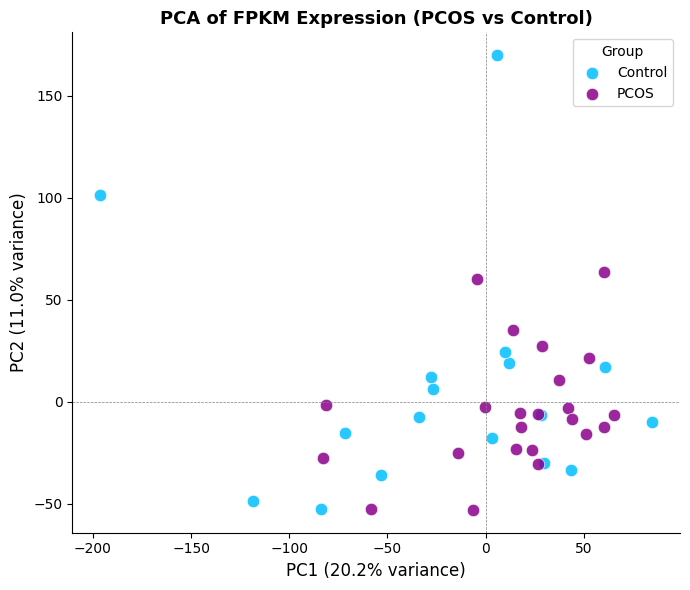

  Saved → outputs/PCA_plot.png


In [8]:
print("\nGenerating PCA plot...")

X      = log2_expr.T.values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

pca    = PCA(n_components=2, random_state=42)
pc     = pca.fit_transform(X_sc)
var_ex = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(pc, columns=["PC1", "PC2"], index=log2_expr.columns)
pca_df["group"] = pca_df.index.map(lambda s: "Control" if s.startswith("Control") else "PCOS")

palette = {"Control": "deepskyblue", "PCOS": "darkmagenta"}

fig, ax = plt.subplots(figsize=(7, 6))
for grp, sub in pca_df.groupby("group"):
    ax.scatter(sub["PC1"], sub["PC2"], label=grp,
               color=palette[grp], s=80, alpha=0.85, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({var_ex[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_ex[1]:.1f}% variance)", fontsize=12)
ax.set_title("PCA of FPKM Expression (PCOS vs Control)", fontsize=13, fontweight="bold")
ax.legend(title="Group", fontsize=10)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
sns.despine(ax=ax)
plt.tight_layout()
pca_path = os.path.join(OUTPUT_DIR, "PCA_plot.png")
plt.savefig(pca_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"  Saved → {pca_path}")

## Sample correlation heatmap

Generating sample correlation heatmap...


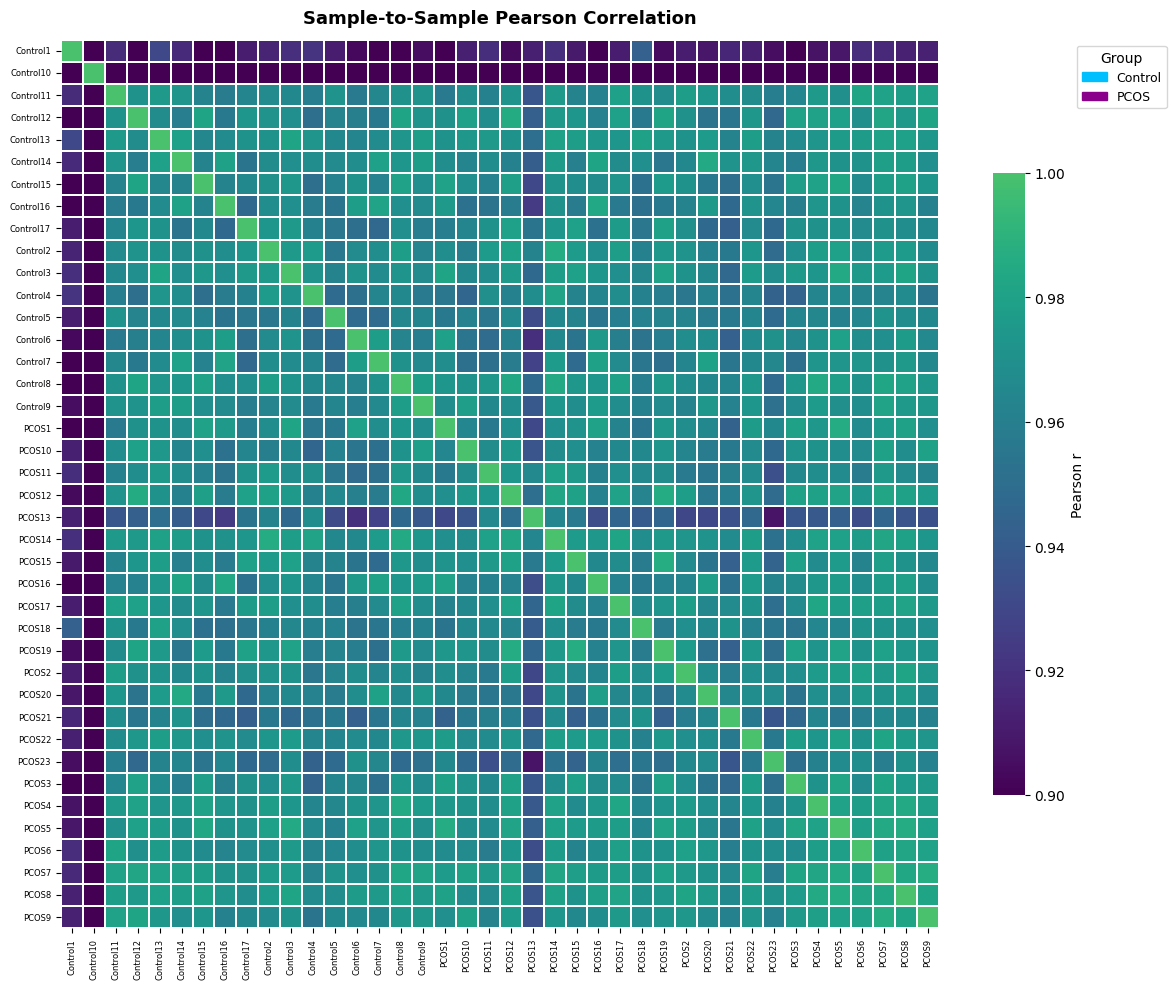

  Saved → outputs/Sample_Correlation_Heatmap.png


In [9]:
print("Generating sample correlation heatmap...")
corr = log2_expr.corr(method="pearson")

group_colours = sample_meta["group"].map(palette)

fig, ax = plt.subplots(figsize=(12, 10))
g = sns.heatmap(
    corr,
    cmap="viridis",
    center=0.97,
    vmin=0.9, vmax=1.0,
    linewidths=0.3,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    ax=ax,
    cbar_kws={"label": "Pearson r", "shrink": 0.7}
)
ax.set_title("Sample-to-Sample Pearson Correlation", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6, rotation=0)

# Add colour legend patches
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches, title="Group", loc="upper left",
          bbox_to_anchor=(1.15, 1), fontsize=9)

plt.tight_layout()
hm_path = os.path.join(OUTPUT_DIR, "Sample_Correlation_Heatmap.png")
plt.savefig(hm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"  Saved → {hm_path}")

## Expression Distrbution

Generating distribution plots...


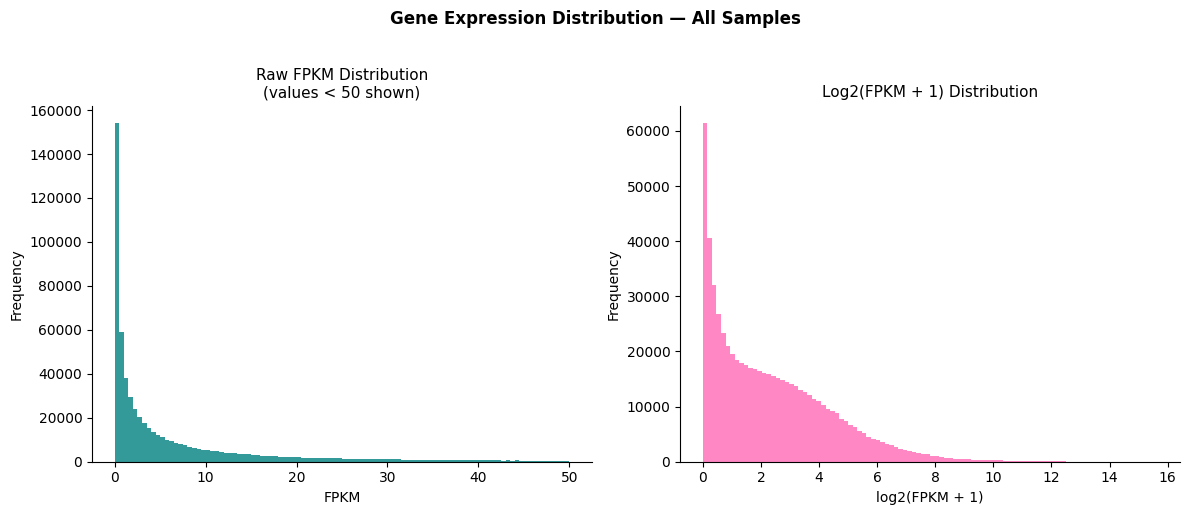

  Saved → outputs/Expression_Distribution.png


In [12]:
print("Generating distribution plots...")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before log2 (raw FPKM, capped at 50 for readability)
raw_vals = expr_filt.values.flatten()
raw_vals = raw_vals[raw_vals < 50]
axes[0].hist(raw_vals, bins=100, color="teal", edgecolor="none", alpha=0.8)
axes[0].set_title("Raw FPKM Distribution\n(values < 50 shown)", fontsize=11)
axes[0].set_xlabel("FPKM"); axes[0].set_ylabel("Frequency")

# After log2
log_vals = log2_expr.values.flatten()
axes[1].hist(log_vals, bins=100, color="hotpink", edgecolor="none", alpha=0.8)
axes[1].set_title("Log2(FPKM + 1) Distribution", fontsize=11)
axes[1].set_xlabel("log2(FPKM + 1)"); axes[1].set_ylabel("Frequency")

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle("Gene Expression Distribution — All Samples", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
dist_path = os.path.join(OUTPUT_DIR, "Expression_Distribution.png")
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"  Saved → {dist_path}")

In [13]:
import shutil
from google.colab import files

# Define the name for the zip file
zip_filename = 'results_for_omics_miniproject.zip'

# Create a zip archive of the OUT_DIR, ensuring the 'results' folder itself is included
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', root_dir='.', base_dir=OUTPUT_DIR)

# Provide a link to download the zip file
files.download(zip_filename)

print(f"[INFO] '{zip_filename}' created and ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[INFO] 'results_for_omics_miniproject.zip' created and ready for download.
